In [1]:
"""

Exploring how to plot the gain modulation due to the autapse

1) plot F-inst/steady versus I for each neuron type.


"""

from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.stimulus import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import random





In [2]:
# import data
SAVE = False
name = "RS_intHD_test"
out_dir = f'.//{name}//'

filename = f"..//{name}.pickle"
with open(filename, 'rb') as file:
    df = pickle.load(file)

print(df.keys())
print(df['f'])
print(df['F_instant'])

Index(['e', 'f', 'tau', 'I_h', 'F_instant', 'F_steady', 'autapse current',
       'autapse delay'],
      dtype='object')
0         0.0
1        50.0
2        50.0
3        50.0
4        50.0
        ...  
1095    250.0
1096    250.0
1097    250.0
1098    250.0
1099    250.0
Name: f, Length: 50100, dtype: float64
0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
1095    136.986301
1096    135.135135
1097    133.333333
1098    129.870130
1099    126.582278
Name: F_instant, Length: 50100, dtype: float64


11
11
5
501
- - - 
94


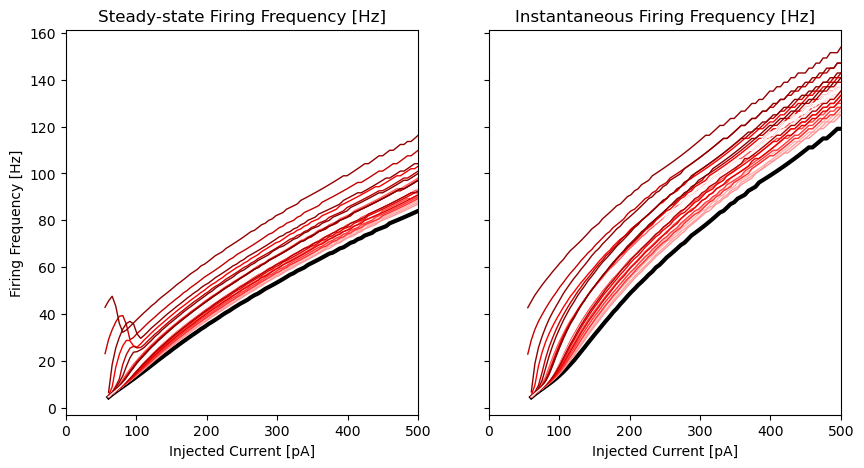

In [ ]:
import matplotlib.colors as mcolors

# plot F vs I for each neuron

e_vals = df["e"].unique()
f_vals = df["f"].unique()
tau_vals = df["tau"].unique()

print(len(e_vals))
print(len(f_vals))
print(len(tau_vals))

fig, ax = plt.subplots(1, 2, figsize = (10, 5), sharey = True)

e_plot = e_vals[::2]
f_plot = f_vals[::2]
tau_plot = np.array([0.])

N_neurons = int(len(df)/len(df['I_h'].unique()))
print(N_neurons)
cmap = plt.get_cmap('seismic')
aut_curr = np.array(df['autapse current'].unique())
print("- - - ")
print(len(aut_curr))
new_colors = cmap(np.linspace(0.5, 1., len(aut_curr)))        # only red colormap
new_cmap = mcolors.LinearSegmentedColormap.from_list('bwr_reds', new_colors)

for e in e_plot:
    for f in f_plot:
        for tau in tau_plot:
            sub_df = df[(df["e"] == e) & (df["f"] == f) & (df["tau"] == tau)]
            
            if len(sub_df['F_instant']) == 0:
                continue

            if e == 0.0 and f == 0.0 and tau == 0.0:
                colour = (0., 0., 0.)
                linewidth = 3
            else:
                neuron_autapse = sub_df['autapse current'].unique()[0]
                idx = np.argwhere(aut_curr == neuron_autapse)[0]
                colour = new_colors[idx]
                linewidth = 1
            
            #plot F_steady
            ax[0].plot(sub_df['I_h'], sub_df['F_steady'], c = colour, linewidth = linewidth)
            # plot F_instant
            ax[1].plot(sub_df['I_h'], sub_df['F_instant'], c = colour, linewidth = linewidth)


ax[0].set_xlabel('Injected Current [pA]')
ax[1].set_xlabel('Injected Current [pA]')
ax[0].set_xlim(df.min(axis = 0)['I_h'], df.max(axis = 0)['I_h'])
ax[1].set_xlim(df.min(axis = 0)['I_h'], df.max(axis = 0)['I_h'])
#ax[0].set_xlim(df.min(axis = 0)['I_h'], 200)
#ax[1].set_xlim(df.min(axis = 0)['I_h'], 200)

ax[0].set_ylabel('Firing Frequency [Hz]')

ax[0].set_title("Steady-state Firing Frequency [Hz]")   
ax[1].set_title("Instantaneous Firing Frequency [Hz]")


if SAVE: plt.savefig(out_dir + "I-O_gain_modulation_poster.png")

100.0
2500.0


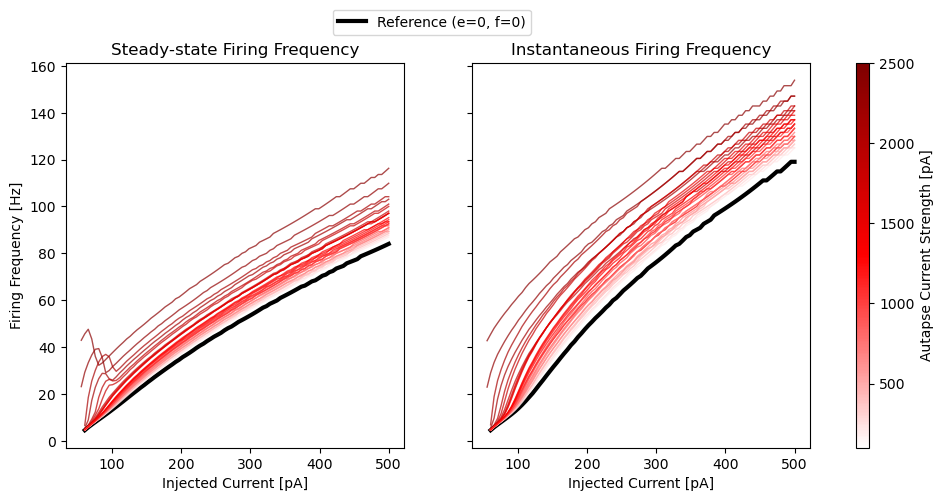

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Define the colormap and normalization
cmap_base = plt.get_cmap('seismic')
aut_curr = np.sort(df['autapse current'].unique()) # Sorted for consistent mapping
aut_curr = aut_curr[~np.isnan(aut_curr)]
new_colors = cmap_base(np.linspace(0.5, 1.0, len(aut_curr)))
new_cmap = mcolors.LinearSegmentedColormap.from_list('bwr_reds', new_colors)

# Create a normalization object for the colorbar
norm = mcolors.Normalize(vmin=aut_curr.min(), vmax=aut_curr.max())
print(aut_curr.min())
print(aut_curr.max())


# We will use this to create a proxy artist for the legend
ref_line = None

for e in e_plot:
    for f in f_plot:
        for tau in tau_plot:
            sub_df = df[(df["e"] == e) & (df["f"] == f) & (df["tau"] == tau)]
            
            if len(sub_df) == 0:
                continue

            if e == 0.0 and f == 0.0 and tau == 0.0:
                colour = (0., 0., 0.)
                linewidth = 3
                label = "Reference (e=0, f=0)"
                # Store the reference line for the legend
                line_ref_0 = ax[0].plot(sub_df['I_h'], sub_df['F_steady'], c=colour, linewidth=linewidth, label=label)
                line_ref_1 = ax[1].plot(sub_df['I_h'], sub_df['F_instant'], c=colour, linewidth=linewidth)
                ref_line = line_ref_0[0]
            else:
                neuron_autapse = sub_df['autapse current'].unique()[0]
                idx = np.argwhere(aut_curr == neuron_autapse)[0]
                colour = new_colors[idx]
                linewidth = 1
                
                ax[0].plot(sub_df['I_h'], sub_df['F_steady'], c=colour, linewidth=linewidth, alpha=0.7)
                ax[1].plot(sub_df['I_h'], sub_df['F_instant'], c=colour, linewidth=linewidth, alpha=0.7)

# --- Add Colorbar ---
# Create a ScalarMappable to link the data to the colormap
sm = plt.cm.ScalarMappable(cmap=new_cmap, norm = norm)
sm.set_array([]) # Required for matplotlib < 3.1

# Position the colorbar. 'ax.ravel().tolist()' tells it to take space from both subplots
cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), pad=0.05, aspect=30)
cbar.set_label('Autapse Current Strength [pA]', fontsize=10)

# --- Add Legend for Reference ---
if ref_line:
    # Create a legend specifically for the reference line, 
    # positioned to clearly distinguish it from the colorbar
    fig.legend(handles=[ref_line], loc='upper center', bbox_to_anchor=(0.43, 1.0), ncol=1)

# Styling
ax[0].set_xlabel('Injected Current [pA]')
ax[1].set_xlabel('Injected Current [pA]')
ax[0].set_ylabel('Firing Frequency [Hz]')
ax[0].set_title("Steady-state Firing Frequency")   
ax[1].set_title("Instantaneous Firing Frequency")

plt.savefig("I-O_gain_modulation_poster.png")
plt.show()